## Import Statements

In [1]:
from astroquery.mast import Observations
from astroquery.mast import Catalogs
from astropy.io import fits
from astropy import table
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

## Use Astroquery to find Observations of WASP-
We begin by doing a cone search usig the `Observations.query_object` function and then filtering for time series observations made by TESS. This leaves us with just the TESS 2-minute cadence data observations. 

In [35]:
star_name = "WASP-44 b"

observations = Observations.query_object(star_name,radius = "0 deg")
obs_wanted = (observations['dataproduct_type'] == 'timeseries') & (observations['obs_collection'] == 'TESS')
print( observations[obs_wanted]['obs_collection', 'project','obs_id'] )

obs_collection project                      obs_id                    
-------------- ------- -----------------------------------------------
          TESS    TESS tess2018263035959-s0003-0000000012862099-0123-s


## Use Astroquery to Dowload DV Products
Use `Observations.get_product_list` to get a list of data products associated with the observations of interest. Each individual observation is associated with several data products, only some of which are the DV products we are interested in. In this case we want those data products that have "productSubGroupDescription" set to either DVT, DVM, DVS or DVR.  

Next, we use `Observations.download_products` to download our selected data files.  This function returns a manifest, a table that contains the local path to the files that are downloaded.

In [36]:
download_dir = str('./data/' + str(star_name.replace(' ', '')))
download_dir

'./data/WASP-44b'

In [37]:
data_products = Observations.get_product_list(observations[obs_wanted])
products_wanted = Observations.filter_products(data_products, 
                                    productSubGroupDescription=["LC"])

print(products_wanted["productFilename"])
manifest = Observations.download_products(products_wanted,download_dir=download_dir)

                    productFilename                    
-------------------------------------------------------
tess2018263035959-s0003-0000000012862099-0123-s_lc.fits


In [38]:
def parse_manifest(manifest):
    """
    Parse manifest and add back columns that are useful for TESS DV exploration.
    """
    results = deepcopy(manifest)
    filenames = []
    sector_range = []
    exts = []
    for i,f in enumerate(manifest['Local Path']):
        file_parts = np.array(np.unique(f.split(sep = '-')))
        sectors = list( map ( lambda x: x[0:2] == 's0', file_parts))
        s1 = file_parts[sectors][0]
        try:
            s2 = file_parts[sectors][1]
        except:
            s2 = s1
        sector_range.append("%s-%s" % (s1,s2))
        path_parts = np.array(f.split(sep = '/'))
        filenames.append(path_parts[-1])
        exts.append(path_parts[-1][-8:])

    results.add_column(table.Column(name = "filename", data = filenames))
    results.add_column(table.Column(name = "sectors", data = sector_range))
    results.add_column(table.Column(name = "fileType", data = exts))
    results.add_column(table.Column(name = "index", data = np.arange(0,len(manifest))))
    
    return results

#Run parser and print
results = parse_manifest(manifest)
print(results['index','sectors','fileType'])

index   sectors   fileType
----- ----------- --------
    0 s0003-s0003 _lc.fits


In [49]:
print(results['index', 'sectors', 'fileType'])

index   sectors   fileType
----- ----------- --------
    0 s0003-s0003 _lc.fits


### Plot the DV Median-Detrended Time Series
The median detrended fluxes are stored in the first extension under 'LC_DETREND'. This is a median detrended version of the light curve that was searched for transit signals. While in the continuous viewing zone, L98-59 was not observed during every sector so there will be gaps in our light curve.

In [51]:
# Locate the file that has the data
want = (results['sectors'] == "s0003-s0003") & (results['fileType'] == "_lc.fits")
dvt_filename = manifest[want]['Local Path'][0]

# Print out the file info
fits.info(dvt_filename)

Filename: ./data/WASP-44b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/tess2018263035959-s0003-0000000012862099-0123-s_lc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  LIGHTCURVE    1 BinTableHDU    167   19692R x 20C   [D, E, J, E, E, E, E, E, E, J, D, E, D, E, D, E, D, E, E, E]   
  2  APERTURE      1 ImageHDU        49   (11, 11)   int32   


In [52]:
# Plot the detrended photometric time series in the first binary table. 
data = fits.getdata(dvt_filename, 1)
time = data['TIME']
relflux = data['LC_DETREND']

plt.figure(figsize = (16,3))
plt.plot (time, relflux, 'b.')
plt.ylim(1.2* np.nanpercentile(relflux, .5) , 1.2 * np.nanpercentile(relflux, 99.5))
plt.title('Data Validation Detrended Light Curve for %s' % (star_name))

KeyError: "Key 'LC_DETREND' does not exist."

### Plot Folded Light Curve
Each extension of the DVT data file contains a separate TCE. After the pipeline finds a set of transits, the transits are removed and the light curve is once again searched for transits.  L98-59 has three TCEs, each is consistent with the three confirmed planets found around this star.  Here we plot the phase folded light curve for each TCE, each as its own subplot.  The DVT file also contains a transit model as one of the columns in the FITS table. We overplot that in orange.

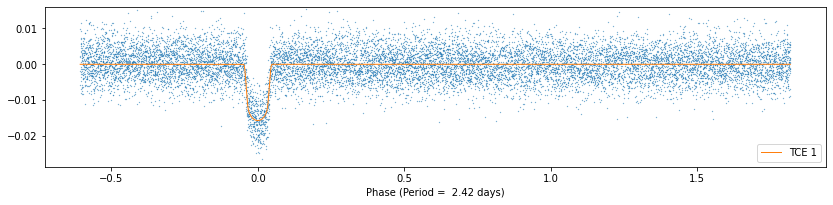

In [29]:
def plot_folded(phase, data, model, ext, period):
    isort = phase.argsort()
    
    plt.plot(phase[isort], data[isort], '.', ms = .5)
    plt.plot(phase[isort], model[isort], '-', lw = 1, label = "TCE %i" % ext)
    plt.xlabel('Phase (Period = %5.2f days)' % period)
    plt.ylim(1.5 * np.nanpercentile(data, .5) , 1.4 * np.nanpercentile(data,99.5))
    plt.legend(loc = "lower right")

plt.figure(figsize = (14,10))

nTCEs = fits.getheader(dvt_filename)['NEXTEND'] - 2

for ext in range(1, nTCEs + 1):
    data = fits.getdata(dvt_filename, ext)
    head = fits.getheader(dvt_filename, ext)
    period = head['TPERIOD']
    phase = data['PHASE']
    flux = data['LC_INIT']
    model = data['MODEL_INIT']
    plt.subplot(3, 1, ext)
    plot_folded(phase, flux, model, ext, period)

<a id="about_ID"></a>
## About this Notebook
**Authors:** 
<br>Susan E. Mullally, STScI 
<br>**Updated On:** 2019-09-13

[Top of Page](#title_ID)
<img style="float: right;" src="https://raw.githubusercontent.com/spacetelescope/notebooks/master/assets/stsci_pri_combo_mark_horizonal_white_bkgd.png" alt="STScI logo" width="200px"/> 